In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv(r"C:\Users\saura\Teen_Mental_Health\Teen_Mental_Health_Dataset.csv")

In [5]:
print('"Feature" : "Data Type"')
for i,j in zip(df.columns, df.dtypes):
    print(f'{i} : {j}')

"Feature" : "Data Type"
age : int64
gender : object
daily_social_media_hours : float64
platform_usage : object
sleep_hours : float64
screen_time_before_sleep : float64
academic_performance : float64
physical_activity : float64
social_interaction_level : object
stress_level : int64
anxiety_level : int64
addiction_level : int64
depression_label : int64


In [4]:
print("first 5 rows of the dataset:")
df.head()

first 5 rows of the dataset:


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [5]:
print('shape of the dataset is:', df.shape)

shape of the dataset is: (1200, 13)


In [6]:
print("basic statistical details of the dataset:")
df.describe()

basic statistical details of the dataset:


,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [7]:
print("basic statistical details of the dataset for object type features:")
df.describe(include='object')

basic statistical details of the dataset for object type features:


,gender,platform_usage,social_interaction_level
count,1200,1200,1200
unique,2,3,3
top,male,Instagram,medium
freq,615,411,416


In [8]:
print('missing values in the dataset:')
print(df.isnull().sum())

missing values in the dataset:
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64


In [9]:
print(df.columns[df.dtypes == 'object'])

Index(['gender', 'platform_usage', 'social_interaction_level'], dtype='object')


In [10]:
for i in ['gender', 'platform_usage', 'social_interaction_level']:
    print('\nValue counts for feature:', i)
    print(df[i].value_counts())


Value counts for feature: gender
gender
male      615
female    585
Name: count, dtype: int64

Value counts for feature: platform_usage
platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64

Value counts for feature: social_interaction_level
social_interaction_level
medium    416
low       415
high      369
Name: count, dtype: int64


In [11]:
df['depression_label'].value_counts()

depression_label
0    1169
1      31
Name: count, dtype: int64

In [12]:
df['depression_label'] = df['depression_label'].map({0: 'No Depression', 1: 'Depression'})

<Axes: title={'center': 'Depression level distribution'}, xlabel='Depression State', ylabel='Count'>

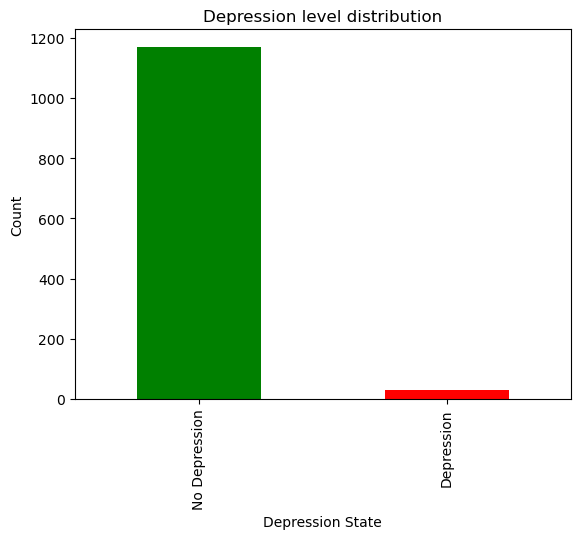

In [13]:
df['depression_label'].value_counts().plot(kind='bar',title='Depression level distribution',xlabel='Depression State',ylabel='Count',color=['green','red'])

In [14]:
num_cols=df.select_dtypes(include=np.number).columns.tolist()
num_cols

['age',
 'daily_social_media_hours',
 'sleep_hours',
 'screen_time_before_sleep',
 'academic_performance',
 'physical_activity',
 'stress_level',
 'anxiety_level',
 'addiction_level']

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'daily_social_media_hours'}>,
        <Axes: title={'center': 'sleep_hours'}>],
       [<Axes: title={'center': 'screen_time_before_sleep'}>,
        <Axes: title={'center': 'academic_performance'}>,
        <Axes: title={'center': 'physical_activity'}>],
       [<Axes: title={'center': 'stress_level'}>,
        <Axes: title={'center': 'anxiety_level'}>,
        <Axes: title={'center': 'addiction_level'}>]], dtype=object)

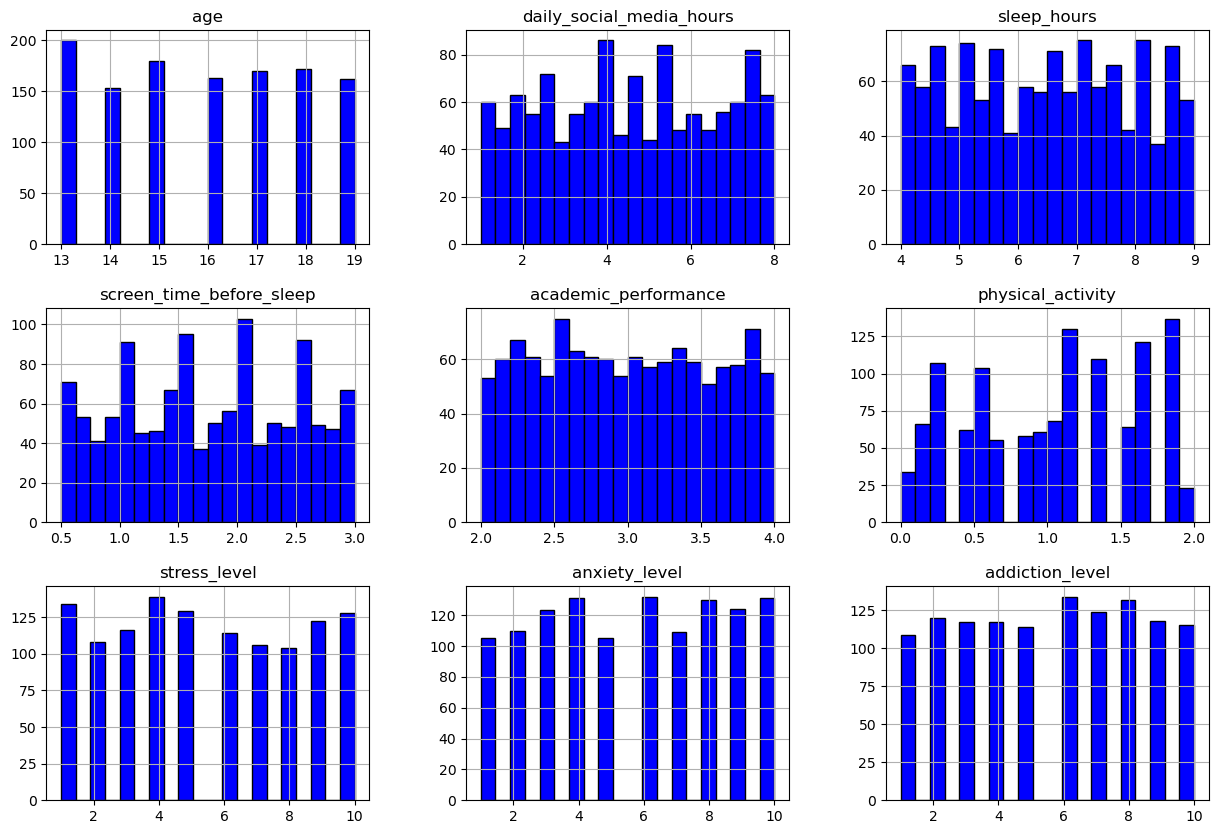

In [15]:
df[num_cols].hist(figsize=(15, 10), bins=20, color='blue', edgecolor='black')

In [16]:
corr_mat=df[num_cols].corr()
print('correlation matrix of the numerical features are:')
print(corr_mat)

correlation matrix of the numerical features are:
                               age  daily_social_media_hours  sleep_hours  \
age                       1.000000                 -0.006635     0.001530   
daily_social_media_hours -0.006635                  1.000000    -0.009472   
sleep_hours               0.001530                 -0.009472     1.000000   
screen_time_before_sleep  0.075612                  0.035777     0.010235   
academic_performance     -0.013973                  0.013179     0.021866   
physical_activity         0.011086                  0.025546     0.012701   
stress_level             -0.031208                  0.030698    -0.010979   
anxiety_level             0.026363                  0.027835    -0.011879   
addiction_level           0.038265                 -0.024964    -0.054838   

                          screen_time_before_sleep  academic_performance  \
age                                       0.075612             -0.013973   
daily_social_media_hours   

In [17]:
df.groupby('depression_label')[num_cols].mean()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level
depression_label,,,,,,,,,
Depression,16.064516,6.719355,4.761290,1.667742,2.995484,0.951613,8.483871,8.612903,5.322581
No Depression,15.924722,4.478785,6.494183,1.742258,2.990248,1.016168,5.365269,5.557742,5.571429


In [18]:
for i in ['gender', 'platform_usage', 'social_interaction_level']:
    print('Crosstab for feature:', i)
    print(pd.crosstab(df[i], df['depression_label']))
    print(pd.crosstab(df[i], df['depression_label'],  normalize='index').round(4) * 100)

Crosstab for feature: gender
depression_label  Depression  No Depression
gender                                     
female                    17            568
male                      14            601
depression_label  Depression  No Depression
gender                                     
female                  2.91          97.09
male                    2.28          97.72
Crosstab for feature: platform_usage
depression_label  Depression  No Depression
platform_usage                             
Both                       9            382
Instagram                 10            401
TikTok                    12            386
depression_label  Depression  No Depression
platform_usage                             
Both                    2.30          97.70
Instagram               2.43          97.57
TikTok                  3.02          96.98
Crosstab for feature: social_interaction_level
depression_label          Depression  No Depression
social_interaction_level                   

In [22]:
import warnings
warnings.filterwarnings('ignore')

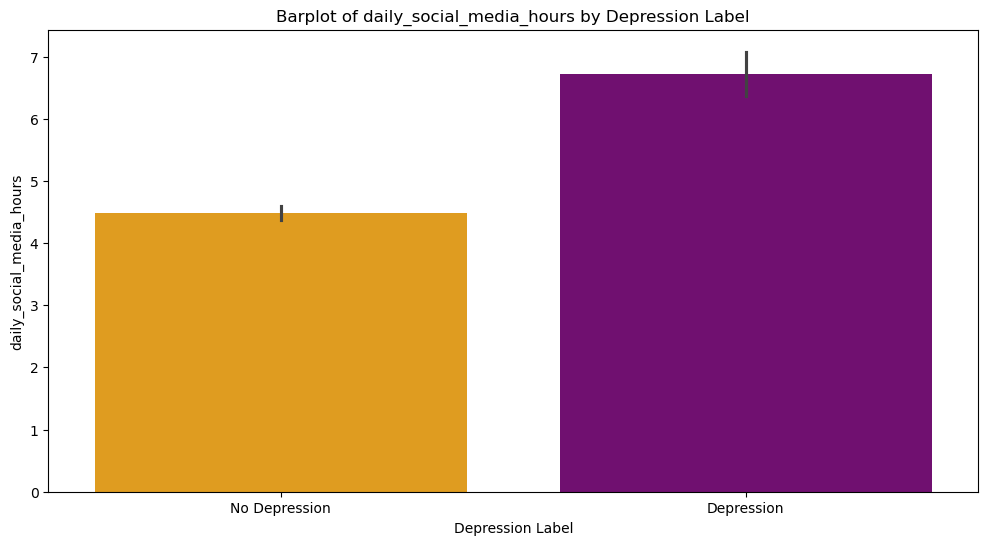

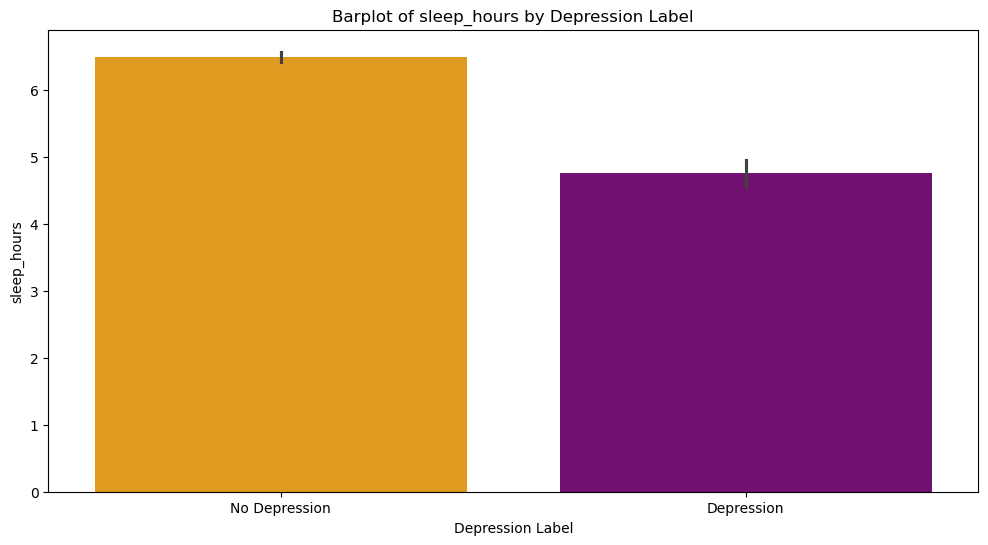

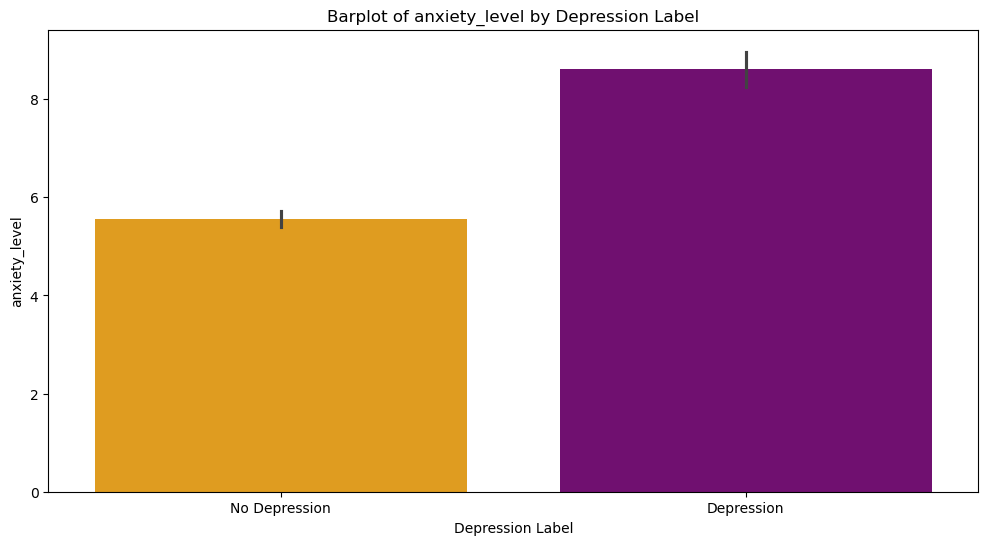

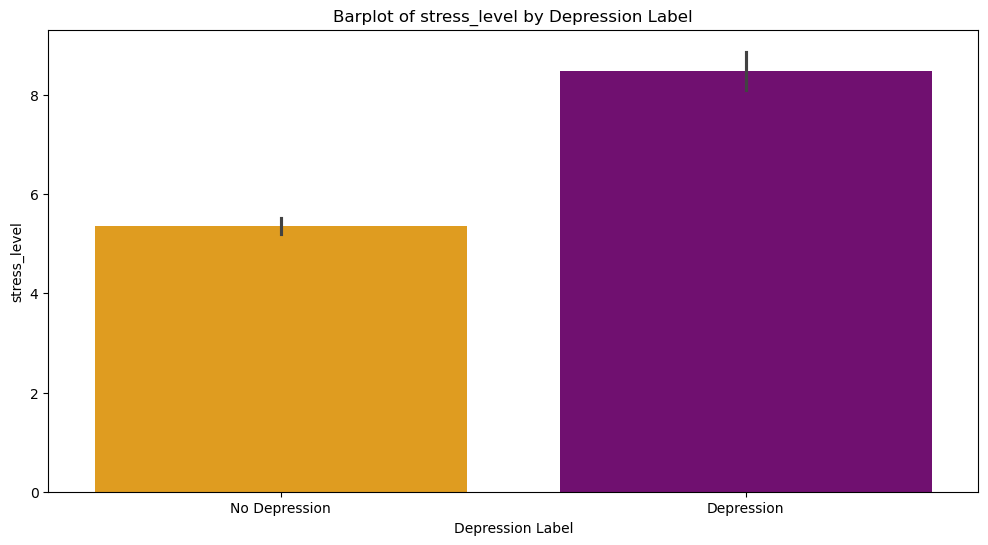

In [23]:
for i in ['daily_social_media_hours','sleep_hours','anxiety_level','stress_level']:
    plt.figure(figsize=(12, 6))
    sns.barplot(x='depression_label', y=i, data=df, palette=['orange','purple'])
    plt.title(f'Barplot of {i} by Depression Label')
    plt.xlabel('Depression Label')
    plt.ylabel(i)
    plt.show()

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score

In [26]:
df_encoded = pd.get_dummies(df, columns=['gender', 'platform_usage', 'social_interaction_level'], drop_first=True)

# Separate X and y
X = df_encoded.drop(columns=['depression_label'])
y = df_encoded['depression_label']

# Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,  stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for column tracking if needed
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# Define models
models = {
    'Logistic Regression (Balanced)': LogisticRegression(class_weight='balanced', random_state=42),
    'Random Forest (Balanced)': RandomForestClassifier(class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Train and evaluate
for name, model in models.items():
    if name == 'Gradient Boosting':
        # Calculate sample weights for Gradient Boosting since it doesn't have class_weight
        neg_weight = 1.0
        pos_weight = len(y_train[y_train=='No Depression']) / len(y_train[y_train=='Depression'])
        sample_weights = np.where(y_train == 1, pos_weight, neg_weight)
        model.fit(X_train_scaled, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_train_scaled, y_train)
        
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    print(f"\n================ {name} ================")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")


================ Logistic Regression (Balanced) ================
Confusion Matrix:
[[  8   1]
 [ 15 336]]

Classification Report:
               precision    recall  f1-score   support

   Depression       0.35      0.89      0.50         9
No Depression       1.00      0.96      0.98       351

     accuracy                           0.96       360
    macro avg       0.67      0.92      0.74       360
 weighted avg       0.98      0.96      0.96       360

ROC-AUC Score: 0.9867

================ Random Forest (Balanced) ================
Confusion Matrix:
[[  2   7]
 [  0 351]]

Classification Report:
               precision    recall  f1-score   support

   Depression       1.00      0.22      0.36         9
No Depression       0.98      1.00      0.99       351

     accuracy                           0.98       360
    macro avg       0.99      0.61      0.68       360
 weighted avg       0.98      0.98      0.97       360

ROC-AUC Score: 1.0000

================ Gradient Boostin

In [27]:
gb_model = models['Gradient Boosting']
importances = gb_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)
print("Gradient Boosting Feature Importances:")
print(feature_imp_df)

rf_model = models['Random Forest (Balanced)']
rf_importances = rf_model.feature_importances_
rf_feature_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': rf_importances}).sort_values(by='Importance', ascending=False)
print("\nRandom Forest Feature Importances:")
print(rf_feature_imp_df)

Gradient Boosting Feature Importances:
                            Feature    Importance
2                       sleep_hours  4.752717e-01
6                      stress_level  2.432744e-01
1          daily_social_media_hours  1.730061e-01
7                     anxiety_level  9.855484e-02
10         platform_usage_Instagram  6.455538e-03
3          screen_time_before_sleep  1.580928e-03
5                 physical_activity  5.127461e-04
4              academic_performance  4.716144e-04
8                   addiction_level  4.590695e-04
0                               age  4.126693e-04
13  social_interaction_level_medium  3.705679e-07
9                       gender_male  0.000000e+00
11            platform_usage_TikTok  0.000000e+00
12     social_interaction_level_low  0.000000e+00

Random Forest Feature Importances:
                            Feature  Importance
2                       sleep_hours    0.236156
6                      stress_level    0.225119
7                     anxiety_l

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Feature Importances in Predicting Teen Depression (Gradient Boosting)', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=300)
plt.close()
print("Saved feature_importances.png")

Saved feature_importances.png


In [29]:
print(df[df['depression_label'] == 'Depression'][['stress_level', 'anxiety_level', 'sleep_hours', 'daily_social_media_hours']].min())
print("\nMax values for non-depressed:")
print(df[df['depression_label'] == 'No Depression'][['stress_level', 'anxiety_level', 'sleep_hours', 'daily_social_media_hours']].max())

stress_level                7.0
anxiety_level               7.0
sleep_hours                 4.1
daily_social_media_hours    5.1
dtype: float64

Max values for non-depressed:
stress_level                10.0
anxiety_level               10.0
sleep_hours                  9.0
daily_social_media_hours     8.0
dtype: float64
